# Cross-Sectional Mean Reversion Signal — Research Notebook

End-to-end research pipeline for a **cross-sectional mean-reversion** signal on crypto OHLCV data.
The core hypothesis: assets that have moved furthest (in absolute or vol-adjusted terms) relative to their peers or their own history will tend to revert over short holding horizons.

| Section | Topic |
|---------|-------|
| §1 | Setup — project root, imports, display options |
| §2 | Configuration — load `configs/research/mean_reversion_signal.yaml` + DB engine |
| §3 | Data — load universe & OHLCV panel |
| §4 | Signal Pipeline — build signal & all feature panels |
| §5 | IC Analysis — per-feature IC / t-stat across all feature families |
| §6 | Diagnostics — IC distribution, rolling IC, coverage, quantiles |
| §7 | Backtest — long/short PnL, fee-tier sensitivity, legs, effective spreads & bounce floor |
| §8 | Execution & Events — rolling Sharpe, execution delay, vol-regime conditioning, market beta |
| §9 | Robustness — lookback × holding × universe-size grid; selection-adjusted significance; walk-forward |
| §10 | Low-turnover construction — pre-specified composite signal traded through hysteresis bands |
| §11 | Detailed findings |

All timestamps are **UTC**; run cells top to bottom (later sections reuse panels built earlier).

**Dependencies:** `cs_mean_reversion`, `cs_momentum`, `momentum_eval`, `execution`, `robustness`, `spreads`, `panel_io`, `research_config`; a populated Postgres DB (OHLCV + universe tables).

## Summary — Key Findings

**Signal:** short-horizon cross-sectional reversal on an hourly spot universe (top-20 Kraken USD pairs, 2020-10 → 2024-06). Headline feature: one-bar return reversal (`reversal_h1`), held 2 bars, filled at real 1-minute prints one minute after the signal close. Costs: 10 bps one-way taker fee (an institutional volume tier, i.e. a systematic fund's cost base) plus half-spread on every fill.

| Metric | Value |
|---|---|
| Tradable IC (NW t) | 0.058 (21.9) |
| Walk-forward out-of-sample IC (NW t) | 0.071 (21.0) |
| Gross Sharpe | 3.7 |
| Net Sharpe, 10 bps fee (flat / per-asset spreads) | −13.1 / −34.0 |
| Net Sharpe, 5 bps top-tier fee | −5.5 |
| Gross edge ÷ bid-ask bounce floor | 0.17× |
| Low-turnover book, gross Sharpe | −1.4 |

- **The effect is real.** It survives execution delay, selection correction and walk-forward re-selection, is market-neutral, and is not a stale-print artifact (§5, §8, §9).
- **It is not tradable by a taker on spot, even at institutional fees.** The gross edge is a fraction of the bid-ask bounce floor, and break-even requires the total cost per fill (fee plus half-spread) to stay below ≈ 2.4 bps, less than the tightest estimated half-spread on its own (§7).
- **Slowing the book down does not help.** A pre-specified composite traded through hysteresis bands cuts turnover ~9× but loses money before costs (§10).
- **Next step:** perpetual futures, with tighter spreads, cheap two-sided shorting and ~10× the breadth.

Supporting evidence for each point is in §11.


## §1 Setup

Locate the project root (`src/` + `configs/`), add it to `sys.path`, and import the mean-reversion signal builders and `momentum_eval` evaluation helpers.

In [1]:
from pathlib import Path
import os
import sys
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "configs").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common.db import make_engine
from src.common.research_config import load_research_settings
from src.data.panel_io import fetch_ohlcv_long, list_universe_symbols

# Minute-level execution modelling (entry/exit at signal close + delta minutes)
from src.research.execution import (
    ExecutionPriceCache,
    assert_zero_delay_consistency,
    run_delay_sweep,
)
from src.research.robustness import run_reversal_grid
from src.research.spreads import estimate_half_spread_bps_from_long

# Mean-reversion feature builders
from src.signals.cs_mean_reversion import (
    build_mean_reversion_signal,
    build_return_reversal_features,
    build_price_zscore_features,
    build_vol_adjusted_move,
    build_extreme_move_indicator,
    build_volume_exhaustion_features,
    build_vwap_distance_features,
    build_rsi_proxy,
    build_range_position,
    build_xsec_rank_of_price_z,
    build_composite_signal,
    get_mean_reversion_feature,
    mean_reversion_feature_lookback,
)

# Momentum feature builders (useful as comparators — momentum and reversal are
# complementary; the same evaluation helpers work for both)
from src.signals.cs_momentum import (
    build_feature_panels as build_momentum_feature_panels,
    compute_forward_returns,
    cross_sectional_rank_or_zscore,
    apply_rebalance_decimation,
    apply_traded_mask,
    build_market_index_returns,
    build_traded_mask,
    estimate_rolling_betas,
    to_simple_returns,
)

# Evaluation helpers (fully reusable from momentum research)
from src.research.momentum_eval import (
    build_quantile_weights,
    build_banded_book,
    compute_ic_series,
    feature_ic_row,
    gross_sharpe,
    portfolio_beta_series,
    realized_beta_diagnostics,
    ic_summary,
    rolling_mean,
    rolling_sharpe,
    run_light_backtest,
    quantile_analysis,
    long_short_leg_returns,
    market_correlation,
    compute_ic_decay_heatmap,
    plot_ic_decay_heatmap,
    max_over_trials_pvalue,
    deflated_sharpe_ratio,
    walk_forward_ic_table,
    walk_forward_selection,
    walk_forward_sharpe_table,
)

pd.options.display.float_format = "{:.4f}".format
# Silence pandas FutureWarnings from downstream resample/ffill calls so the
# notebook output stays readable; revisit when the project pins a newer pandas.
warnings.filterwarnings("ignore", category=FutureWarning)

## §2 Configuration

Load research parameters from `configs/research/mean_reversion_signal.yaml` and open the DB engine. Key knobs: signal timeframe, reversal lookback, vol/VWAP/RSI/range window lengths, cross-sectional transform, fee/spread assumptions, and the train/test split date. Feature horizons here are shorter than in the momentum config: mean reversion operates on 1–24h windows, not days or weeks.

In [2]:
settings = load_research_settings("configs/research/mean_reversion_signal.yaml")
engine = make_engine(settings)

settings_preview_keys = [
    "signal_timeframe",
    "reversal_lookback_bars",
    "holding_period_bars",
    "execution_delay_bars",
    "ic_rebalance_bars",
    "use_minute_execution",
    "execution_delay_minutes",
    "execution_delay_minutes_grid",
    "log_returns",
    "price_zscore_window_bars",
    "bollinger_window_bars",
    "vol_window_bars",
    "vwap_window_bars",
    "volume_window_bars",
    "rsi_window_bars",
    "range_position_window_bars",
    "extreme_move_threshold_sigma",
    "feature_horizons_bars",
    "cross_sectional_transform",
    "benchmark_symbol",
    "data_start_date",
    "data_end_date",
    "train_split_date",
    "max_assets",
    "top_quantile",
    "bottom_quantile",
    "fee_bps",
    "half_spread_bps",
]

{k: settings[k] for k in settings_preview_keys}

{'signal_timeframe': '1h',
 'reversal_lookback_bars': 2,
 'holding_period_bars': 2,
 'execution_delay_bars': 0,
 'ic_rebalance_bars': 2,
 'use_minute_execution': True,
 'execution_delay_minutes': 1,
 'execution_delay_minutes_grid': [0, 1, 5, 15, 30, 60],
 'log_returns': True,
 'price_zscore_window_bars': 24,
 'bollinger_window_bars': 20,
 'vol_window_bars': 14,
 'vwap_window_bars': 24,
 'volume_window_bars': 24,
 'rsi_window_bars': 14,
 'range_position_window_bars': 12,
 'extreme_move_threshold_sigma': 2.0,
 'feature_horizons_bars': [1, 2, 4, 6],
 'cross_sectional_transform': 'rank',
 'benchmark_symbol': 'XBT/USD',
 'data_start_date': Timestamp('2020-09-30 23:59:59+0000', tz='UTC'),
 'data_end_date': Timestamp('2024-06-30 23:59:59+0000', tz='UTC'),
 'train_split_date': Timestamp('2022-06-30 23:59:59+0000', tz='UTC'),
 'max_assets': 20,
 'top_quantile': 0.2,
 'bottom_quantile': 0.2,
 'fee_bps': 10.0,
 'half_spread_bps': 1.0}

## §3 Data

Pull the **monthly rebalance universe** (rank-filtered liquid names) and long-format OHLCV for the research date range. This is the only cell that hits the database; all downstream sections work in-memory on `df_long`. Mean-reversion features also require **volume** (for VWAP and volume-exhaustion features), so `volume_wide` is retained alongside `close_wide`.

In [3]:
# Optionally restrict to monthly universe members.
if settings.get("use_monthly_universe", True):
    universe_df = list_universe_symbols(
        engine,
        as_of_date=None,
        top_n=settings.get("max_assets"),
    )
    universe_df["rebalance_date"] = pd.to_datetime(universe_df["rebalance_date"], utc=True)
    universe_df = universe_df[
        (universe_df["rebalance_date"] >= settings["data_start_date"].normalize())
        & (universe_df["rebalance_date"] <= settings["data_end_date"].normalize())
    ]
    symbols = sorted(universe_df["symbol"].unique().tolist())
    print(f"Universe snapshots loaded: {len(universe_df)} rows, "
          f"{universe_df['rebalance_date'].nunique()} months")
else:
    universe_df = None
    symbols = None

df_long = fetch_ohlcv_long(
    engine,
    start_ts=settings["data_start_date"],
    end_ts=settings["data_end_date"],
    symbols=symbols,
)

print(f"\nRaw OHLCV rows : {len(df_long):,}")
print(f"Symbols        : {df_long['symbol'].nunique()}")
print(f"Date range     : {df_long['ts'].min()} -> {df_long['ts'].max()}")
print(f"Monthly points : {0 if universe_df is None else universe_df['rebalance_date'].nunique()}")
df_long.head(3)

Universe snapshots loaded: 669 rows, 43 months

Raw OHLCV rows : 1,704,347
Symbols        : 64
Date range     : 2020-10-01 00:00:00+00:00 -> 2024-06-30 23:00:00+00:00
Monthly points : 43


,ts,symbol,open,high,low,close,volume,trades,dollar_volume
0,2020-10-01 00:00:00+00:00,ADA/USD,0.1015,0.1030,0.1013,0.1025,560347.3378,76,57428.3176
1,2020-10-01 00:00:00+00:00,ALGO/USD,0.3467,0.3482,0.3440,0.3463,27848.4159,31,9645.2989
2,2020-10-01 00:00:00+00:00,ATOM/USD,5.3753,5.4484,5.3753,5.4233,520.9104,19,2825.0531


## §4 Signal Pipeline

Build the core mean-reversion signal and **all feature panels** in one pass.  Feature families:

| Family | Builder | Core idea |
|--------|---------|----------|
| Return Reversal | `build_return_reversal_features` | Negate short-term returns |
| Price Z-Score / Bollinger | `build_price_zscore_features` | Distance from rolling mean |
| Vol-Adjusted Move | `build_vol_adjusted_move` | Return scaled by trailing vol |
| Extreme Move | `build_extreme_move_indicator` | Identify outsized single-bar moves |
| Volume Exhaustion | `build_volume_exhaustion_features` | Move size conditioned on volume |
| VWAP Distance | `build_vwap_distance_features` | Distance from rolling VWAP / MA |
| RSI Proxy | `build_rsi_proxy` | Overbought/oversold |
| Range Position (%K) | `build_range_position` | Position within recent high-low range |
| XSec Rank of Price-Z | `build_xsec_rank_of_price_z` | Relative stretch vs peers |

Momentum feature panels are also computed as a benchmark comparison.

In [4]:
# --- Core pipeline -----------------------------------------------------------
pipeline = build_mean_reversion_signal(
    df_long,
    signal_timeframe=settings["signal_timeframe"],
    reversal_lookback_bars=settings["reversal_lookback_bars"],
    universe_df=universe_df,
    cross_sectional_transform=settings["cross_sectional_transform"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    log_returns=settings["log_returns"],
    ic_rebalance_bars=settings["ic_rebalance_bars"],
)

close_wide    = pipeline["close_wide"]
volume_wide   = pipeline["volume_wide"]
return_wide   = pipeline["return_wide"]
signal        = pipeline["signal"]
signal_fresh  = pipeline["signal_fresh"]
universe_mask = pipeline["universe_mask"]

# --- Forward returns ---------------------------------------------------------
fwd_ret = compute_forward_returns(
    close_wide,
    holding_period_bars=settings["holding_period_bars"],
    log_returns=settings["log_returns"],
)

# Universe-masked panels keep IC diagnostics aligned to the tradable universe.
def _mask_to_universe(panel):
    if universe_mask is None:
        return panel
    aligned_mask = universe_mask.reindex(index=panel.index, columns=panel.columns).fillna(False)
    return panel.where(aligned_mask)

xsec_universe_fwd_ret = _mask_to_universe(fwd_ret)
analysis_fwd_ret = xsec_universe_fwd_ret

horizons = settings["feature_horizons_bars"]

# --- Mean-reversion feature panels ------------------------------------------
feat_reversal   = build_return_reversal_features(
    close_wide, horizons, log_returns=settings["log_returns"],
    universe_mask=universe_mask,
)
feat_price_z    = build_price_zscore_features(
    close_wide,
    price_zscore_window_bars=settings["price_zscore_window_bars"],
    bollinger_window_bars=settings["bollinger_window_bars"],
)
feat_vol_adj    = build_vol_adjusted_move(
    close_wide, horizons,
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
)
feat_extreme    = build_extreme_move_indicator(
    close_wide,
    vol_window_bars=settings["vol_window_bars"],
    threshold_sigma=settings["extreme_move_threshold_sigma"],
    log_returns=settings["log_returns"],
)
feat_vol_exh    = build_volume_exhaustion_features(
    close_wide, volume_wide, horizons,
    volume_window_bars=settings["volume_window_bars"],
    log_returns=settings["log_returns"],
)
feat_vwap       = build_vwap_distance_features(
    close_wide, volume_wide,
    vwap_window_bars=settings["vwap_window_bars"],
    ma_window_bars=settings["vwap_window_bars"],
)
feat_rsi        = build_rsi_proxy(
    close_wide,
    rsi_window_bars=settings["rsi_window_bars"],
    log_returns=settings["log_returns"],
)
feat_range      = build_range_position(
    close_wide,
    range_window_bars=settings["range_position_window_bars"],
)
feat_xsec_z     = build_xsec_rank_of_price_z(
    close_wide,
    price_zscore_window_bars=settings["price_zscore_window_bars"],
    min_assets_per_timestamp=settings["min_assets_per_timestamp"],
)

# --- Momentum feature panels (for comparison) --------------------------------
mom_feat_panels = build_momentum_feature_panels(
    close_wide,
    horizons=horizons,
    benchmark_symbol=settings["benchmark_symbol"],
    vol_window_bars=settings["vol_window_bars"],
    log_returns=settings["log_returns"],
    universe_mask=universe_mask,
)

print("Panel shapes summary:")
print(f"  close_wide  : {close_wide.shape}")
print(f"  volume_wide : {volume_wide.shape}")
print(f"  fwd_ret     : {fwd_ret.shape}")
print(f"  signal      : {signal.shape}")
print(f"  horizons    : {horizons}")

Panel shapes summary:
  close_wide  : (32856, 64)
  volume_wide : (32856, 64)
  fwd_ret     : (32856, 64)
  signal      : (32856, 64)
  horizons    : [1, 2, 4, 6]


In [5]:
# --- Execution-priced returns (shared by tradable IC and all backtests) ------
# One cache so §5/§6 IC and §7+ backtests price off the SAME execution model.
# For signal bar t (close known at t+1h), fills are the last real 1m close
# at-or-before t+1h+delta (see src/research/execution.py).
exec_prices = ExecutionPriceCache(engine, close_wide)

# Tradable forward returns at the headline delay: the return actually
# harvestable (entry t+delta, exit t+H+delta), with stale LOCF / signal-close
# fills excluded via the direct-fill mask. PRIMARY target for the IC analysis
# below; close-to-close `analysis_fwd_ret` is the raw-predictive-power
# reference. (Distinct from the §5 traded-bar mask, which removes no-trade
# *bars* from close-to-close IC: that isolates staleness, this latency.)
_H_ic = int(settings["holding_period_bars"])
if settings["use_minute_execution"]:
    _delta_ic = int(settings["execution_delay_minutes"])
    tradable_exec_close = exec_prices.close_panel(_delta_ic)
    tradable_fwd_ret = _mask_to_universe(
        exec_prices.forward_returns(
            _delta_ic, holding_period_bars=_H_ic, log_returns=settings["log_returns"]
        )
    )
    print(f"Tradable IC target: exec returns at delta={_delta_ic}m, H={_H_ic} bars")
else:
    tradable_exec_close = close_wide
    tradable_fwd_ret = analysis_fwd_ret
    print("Minute execution off: tradable IC target falls back to close-to-close")


Tradable IC target: exec returns at delta=1m, H=2 bars


## §5 IC Analysis

Raw short-term returns should show *negative* mean IC (recent winners underperform) — this confirms the reversal hypothesis. After negation, all mean-reversion feature builders return already-negated values, so positive IC is expected throughout the comparison table.

**Tradable vs close-to-close IC.** Close-to-close IC measures raw predictive power but assumes entry at the very close that formed the signal. Tradable IC scores the same signal against execution-priced returns (entry at the last real 1-minute print one minute after the signal close, exit H bars later at the same offset), i.e. the return a taker could actually capture. Tradable IC drives feature selection; the gap between the two (the IC haircut) is the predictive power lost to execution latency.

Newey-West lag accounts for overlapping forward returns, lookback windows, and rebalance decimation.

In [6]:
# --- Feature family comparison table ----------------------------------------
# Each row is one (feature_name, horizon) combo.
# Features without a horizon dimension appear once.
# Horizon-aware features pass their own lookback in `lookback_bars` so the
# NW lag absorbs that overlap exactly. Features without one default to the
# reversal lookback R.

records = []

H   = settings["holding_period_bars"]
R   = settings["reversal_lookback_bars"]
D   = settings["ic_rebalance_bars"]
min_assets = settings["min_assets_per_timestamp"]
# The scan runs on the raw (undecimated) signals, so the NW lag is the last
# overlapping lag in bars: max(H, lookback) - 1.

def _add(name, panel, lookback_bars=None):
    # Tradable IC (execution-priced, entry t+delta) drives selection; the
    # close-to-close columns are the raw-signal baseline.
    local_lookback = R if lookback_bars is None else int(lookback_bars)
    row = feature_ic_row(
        _mask_to_universe(panel),
        analysis_fwd_ret,
        nw_lag=max(H, local_lookback) - 1,
        min_assets=min_assets,
        tradable_forward_return_wide=tradable_fwd_ret,
    )
    row["feature"] = name
    records.append(row)

# Return reversal
for h in horizons:
    _add(f"reversal_h{h}",       feat_reversal[h]["reversal"],      lookback_bars=h)
    _add(f"xsec_reversal_h{h}",  feat_reversal[h]["xsec_reversal"], lookback_bars=h)

# Price z-score / Bollinger band-touch
_add("price_zscore",     feat_price_z["price_zscore"],
     lookback_bars=settings["price_zscore_window_bars"])
_add("bollinger_touch",  feat_price_z["bollinger_touch"],
     lookback_bars=settings["bollinger_window_bars"])

# Vol-adjusted move
for h in horizons:
    _add(f"vol_adj_reversal_h{h}",      feat_vol_adj[h]["vol_adj_reversal"],      lookback_bars=h)
    _add(f"vol_adj_xsec_reversal_h{h}", feat_vol_adj[h]["vol_adj_xsec_reversal"], lookback_bars=h)

# Extreme move (single-bar z-score → lookback is 1, vol estimation window is separate)
_add("extreme_signed_z", feat_extreme["signed_z"],     lookback_bars=1)
_add("extreme_flag",     feat_extreme["extreme_flag"], lookback_bars=1)

# Volume exhaustion
for h in horizons:
    _add(f"vol_exhaustion_h{h}", feat_vol_exh[h]["vol_exhaustion"], lookback_bars=h)
    _add(f"vol_blowoff_h{h}",    feat_vol_exh[h]["vol_blowoff"],    lookback_bars=h)

# VWAP / MA distance (single-bar deviation from rolling anchor)
_add("distance_from_vwap", feat_vwap["distance_from_vwap"], lookback_bars=1)
_add("distance_from_ma",   feat_vwap["distance_from_ma"],   lookback_bars=1)

# RSI proxy
_add("rsi_proxy",          feat_rsi["rsi_proxy"],
     lookback_bars=settings["rsi_window_bars"])

# Range position
_add("range_position",     feat_range["range_position"],
     lookback_bars=settings["range_position_window_bars"])

# XSec rank of price z
_add("xsec_rank_price_z",  feat_xsec_z["xsec_rank_price_z"],
     lookback_bars=settings["price_zscore_window_bars"])

# Momentum features (for comparison — expect lower/opposite IC)
for h, ret_wide in mom_feat_panels["core_returns"].items():
    _add(f"momentum_core_h{h}",         ret_wide,                       lookback_bars=h)
for h, rel in mom_feat_panels["relative_features"].items():
    _add(f"momentum_xsec_mean_h{h}",    rel["minus_xsec_mean"],         lookback_bars=h)
for h, va in mom_feat_panels["vol_adjusted_features"].items():
    _add(f"momentum_return_over_vol_h{h}", va["return_over_vol"],       lookback_bars=h)

ic_table = (
    pd.DataFrame(records)
    .set_index("feature")
    [["mean_ic", "mean_ic_trad", "ic_haircut", "t_stat_ic_nw", "t_nw_trad",
      "n_obs", "nw_lag"]]
    .sort_values("t_nw_trad", ascending=False)
)

print("=== Feature IC Comparison (tradable + close-to-close, sorted by tradable NW t) ===")
print(ic_table.to_string())

# Identify best mean-reversion feature for downstream analysis.
mr_features_mask = ~ic_table.index.str.startswith("momentum_")
best_mr_feature_name = ic_table.loc[mr_features_mask]["t_nw_trad"].idxmax()
print(f"\nBest mean-reversion feature: {best_mr_feature_name}")

=== Feature IC Comparison (tradable + close-to-close, sorted by tradable NW t) ===
                             mean_ic  mean_ic_trad  ic_haircut  t_stat_ic_nw  t_nw_trad  n_obs  nw_lag
feature                                                                                               
reversal_h1                   0.0698        0.0572      0.0125       37.8614    31.2213  29880       1
xsec_reversal_h1              0.0698        0.0572      0.0125       37.8614    31.2213  29880       1
reversal_h2                   0.0705        0.0616      0.0089       34.4963    30.2074  29884       1
xsec_reversal_h2              0.0705        0.0616      0.0089       34.4963    30.2074  29884       1
reversal_h4                   0.0653        0.0608      0.0045       29.1521    27.2014  29887       3
xsec_reversal_h4              0.0653        0.0608      0.0045       29.1521    27.2014  29887       3
vol_blowoff_h1                0.0555        0.0451      0.0104       31.4014    25.6403  2988

### Stale-Print Contribution — Traded-Bar Mask

The hourly loader forward-fills no-trade hours (`trades = 0`), so some closes are stale copies of an older print. Stale prints mechanically **inflate** measured reversal: an asset with a stale bar shows a 0% return while peers move, ranks as a cross-sectional "loser", then "reverts" when its next real trade catches up (non-synchronous trading). The minute-execution panel has the same exposure through its LOCF fallbacks on illiquid names.

The table below recomputes the headline features' IC requiring **both feature endpoints** (`t`, `t−h`) and **both forward-return endpoints** (`t`, `t+H`) to be real prints. The masked column is the clean estimate of the reversal effect; the delta is the stale-print artifact.


In [7]:
# --- Traded-bar mask: how much of the reversal IC is stale prints? -----------
traded_mask = build_traded_mask(df_long, settings["signal_timeframe"])

# Prevalence: share of in-universe, priced cells whose bar had no real trade.
_univ_cells = close_wide.notna()
if universe_mask is not None:
    _univ_cells &= universe_mask.reindex(
        index=close_wide.index, columns=close_wide.columns, fill_value=False
    ).astype(bool)
_aligned_traded = traded_mask.reindex(
    index=close_wide.index, columns=close_wide.columns, fill_value=False
).astype(bool)
stale_share = float((_univ_cells & ~_aligned_traded).sum().sum() / _univ_cells.sum().sum())
print(f"Stale (no-trade) share of in-universe bars: {stale_share:.2%}")

fwd_ret_traded = apply_traded_mask(analysis_fwd_ret, traded_mask, forward_bars=H)

mask_rows = []
_mask_candidates = [(f"reversal_h{h}", feat_reversal[h]["reversal"], h) for h in horizons]
_mask_candidates += [
    ("extreme_signed_z",   feat_extreme["signed_z"],        1),
    ("distance_from_vwap", feat_vwap["distance_from_vwap"], 1),
]
for _name, _panel, _lb in _mask_candidates:
    _panel_u = _mask_to_universe(_panel)
    _nw_loc = max(H, _lb) - 1
    _s_all = ic_summary(
        compute_ic_series(_panel_u, analysis_fwd_ret, min_assets=min_assets),
        nw_lag=_nw_loc,
    )
    _s_msk = ic_summary(
        compute_ic_series(
            apply_traded_mask(_panel_u, traded_mask, lookback_bars=_lb),
            fwd_ret_traded,
            min_assets=min_assets,
        ),
        nw_lag=_nw_loc,
    )
    mask_rows.append({
        "feature": _name,
        "mean_ic_all": _s_all["mean_ic"],
        "mean_ic_traded_only": _s_msk["mean_ic"],
        "stale_artifact": _s_all["mean_ic"] - _s_msk["mean_ic"],
        "t_nw_all": _s_all["t_stat_ic_nw"],
        "t_nw_traded_only": _s_msk["t_stat_ic_nw"],
        "n_obs_traded_only": _s_msk["n_obs"],
    })

stale_ic_table = pd.DataFrame(mask_rows).set_index("feature")
print("\n=== Reversal IC: all bars vs real-print bars only ===")
print(stale_ic_table.to_string())
_worst_name = stale_ic_table["stale_artifact"].idxmax()
_worst = float(stale_ic_table.loc[_worst_name, "stale_artifact"])
print(f"\nLargest stale-print artifact: {_worst:+.4f} IC on {_worst_name} "
      f"({_worst / stale_ic_table.loc[_worst_name, 'mean_ic_all']:.0%} of its unmasked IC)")


Stale (no-trade) share of in-universe bars: 0.11%

=== Reversal IC: all bars vs real-print bars only ===
                    mean_ic_all  mean_ic_traded_only  stale_artifact  t_nw_all  t_nw_traded_only  n_obs_traded_only
feature                                                                                                            
reversal_h1              0.0698               0.0698          0.0000   37.8614           37.8536              29864
reversal_h2              0.0705               0.0704          0.0001   34.4963           34.4104              29860
reversal_h4              0.0653               0.0652          0.0001   29.1521           29.0811              29853
reversal_h6              0.0616               0.0615          0.0001   26.6330           26.5489              29851
extreme_signed_z         0.0480               0.0479          0.0000   27.2142           27.1975              29864
distance_from_vwap       0.0558               0.0557          0.0001   25.1314     

### IC Decay Heatmap — Signal × Holding Period

This heatmap sweeps candidate mean-reversion signals across a grid of holding periods and reports the Newey-West-adjusted IC t-stat for each. For mean reversion the expectation is a steep decay: t-stats should peak at *h = 1* (one 1h bar) and fall away quickly, confirming the edge is short-lived and execution-sensitive. A signal whose t-stat holds flat across the grid instead of decaying shows unexpected persistence and may be capturing a momentum effect rather than genuine reversion.

**Newey-West lag.** Overlapping windows induce serial correlation in the IC series, so the iid t-stat is too optimistic. Two IC observations stay correlated as long as they share *either* forward-return data (up to `H − 1` bars apart) *or* signal-lookback data (up to `R − 1` bars apart), so the binding truncation lag is `max(H, R) − 1` — the *larger* of the two overlaps, not their sum. Using `nw_lag = 0` would understate the standard error and inflate the t-stat at longer horizons.

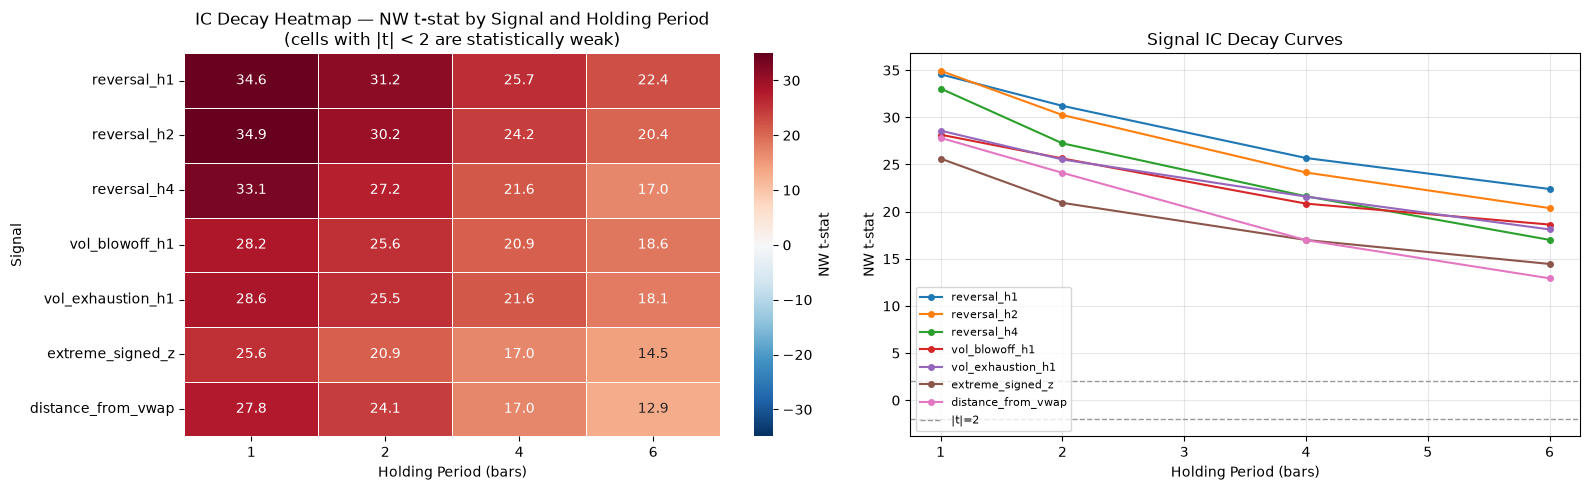

Signal                    | Peak hold |   Peak t |  t @ h=1 | Zero-cross hold
------------------------------------------------------------------------
reversal_h1               |         1 |    34.56 |    34.56 | >max (6)
reversal_h2               |         1 |    34.94 |    34.94 | >max (6)
reversal_h4               |         1 |    33.05 |    33.05 | >max (6)
vol_blowoff_h1            |         1 |    28.16 |    28.16 | >max (6)
vol_exhaustion_h1         |         1 |    28.59 |    28.59 | >max (6)
extreme_signed_z          |         1 |    25.62 |    25.62 | >max (6)
distance_from_vwap        |         1 |    27.83 |    27.83 | >max (6)

IC haircut (close-to-close minus tradable) for reversal_h1, by holding period:
holding_period_bars
1   0.0163
2   0.0126
4   0.0082
6   0.0068


In [8]:
holding_period_grid = [1, 2, 4, 6]

# Raw and xsec variants of the same underlying are highly correlated — pick one.
# Candidates: the leading features from the IC table above.
candidate_signals_raw = {
    "reversal_h1":        feat_reversal[1]["reversal"],
    "reversal_h2":        feat_reversal[2]["reversal"],
    "reversal_h4":        feat_reversal[4]["reversal"],
    "vol_blowoff_h1":     feat_vol_exh[1]["vol_blowoff"],
    "vol_exhaustion_h1":  feat_vol_exh[1]["vol_exhaustion"],
    "extreme_signed_z":   feat_extreme["signed_z"],
    "distance_from_vwap": feat_vwap["distance_from_vwap"],
}
candidate_signals = {k: _mask_to_universe(v) for k, v in candidate_signals_raw.items()}

# Feature lookback for each signal — drives NW lag = max(feature_horizon, h) - 1.
# Matches the lookback_bars passed for each feature in the IC table above.
feature_horizons = {
    "reversal_h1":        1,
    "reversal_h2":        2,
    "reversal_h4":        4,
    "vol_blowoff_h1":     1,
    "vol_exhaustion_h1":  1,
    "extreme_signed_z":   1,
    "distance_from_vwap": 1,
}

# Tradable decay surface: feeding the execution-close panel makes the
# internal forward returns execution-priced (entry t+delta, exit t+h+delta),
# so this is the harvestable IC by holding period, which is what we select on.
_hm_close = tradable_exec_close if settings["use_minute_execution"] else close_wide
t_stat_heatmap, mean_ic_heatmap = compute_ic_decay_heatmap(
    candidate_signals=candidate_signals,
    close_wide=_hm_close,
    holding_period_grid=holding_period_grid,
    log_returns=settings["log_returns"],
    min_assets=settings["min_assets_per_timestamp"],
    feature_horizons=feature_horizons,
)

plot_ic_decay_heatmap(t_stat_heatmap)

# IC haircut vs close-to-close for a reference signal: how much predictive
# power survives the execution delay, by holding period.
if settings["use_minute_execution"]:
    _ref = "reversal_h1" if "reversal_h1" in candidate_signals else list(candidate_signals)[0]
    _, _c2c_mean_ic = compute_ic_decay_heatmap(
        candidate_signals={_ref: candidate_signals[_ref]},
        close_wide=close_wide,
        holding_period_grid=holding_period_grid,
        log_returns=settings["log_returns"],
        min_assets=settings["min_assets_per_timestamp"],
        feature_horizons={_ref: feature_horizons[_ref]},
    )
    print(f"\nIC haircut (close-to-close minus tradable) for {_ref}, by holding period:")
    print((_c2c_mean_ic.loc[_ref] - mean_ic_heatmap.loc[_ref]).round(4).to_string())

In [9]:
# ---- Select signal and holding period based on IC decay heatmap above -------
selected_feature_name           = 'reversal_h1'
apply_xsec_transform            = True
apply_rebalance_decimation_flag = True

# Single trading-cadence knob: the backtest rebalances every
# `selected_holding_period` bars on a fresh signal and holds those H bars.
# Decimation via ic_rebalance_bars is an IC-analysis device only and does
# not feed the backtest.
selected_holding_period = int(settings["holding_period_bars"])

fwd_ret = compute_forward_returns(
    close_wide, holding_period_bars=selected_holding_period, log_returns=settings["log_returns"]
)
analysis_fwd_ret = _mask_to_universe(fwd_ret)

if settings["use_minute_execution"]:
    tradable_fwd_ret = _mask_to_universe(
        exec_prices.forward_returns(
            int(settings["execution_delay_minutes"]),
            holding_period_bars=selected_holding_period,
            log_returns=settings["log_returns"],
        )
    )
else:
    tradable_fwd_ret = analysis_fwd_ret

mr_feature_packs = {
    "reversal": feat_reversal, "price_z": feat_price_z, "vol_adj": feat_vol_adj,
    "extreme": feat_extreme, "vol_exh": feat_vol_exh, "vwap": feat_vwap,
    "rsi": feat_rsi, "range": feat_range, "xsec_z": feat_xsec_z,
}
selected_lookback = mean_reversion_feature_lookback(selected_feature_name, settings)
raw_panel = _mask_to_universe(
    get_mean_reversion_feature(selected_feature_name, mr_feature_packs)
)

if apply_xsec_transform:
    selected_signal_fresh = cross_sectional_rank_or_zscore(
        raw_panel,
        method=settings["cross_sectional_transform"],
        min_assets_per_timestamp=settings["min_assets_per_timestamp"],
    )
else:
    selected_signal_fresh = raw_panel

# Decimated copy for IC analysis only ("what does the held signal
# predict?"). All backtests below consume selected_signal_fresh.
if apply_rebalance_decimation_flag and D > 1:
    selected_signal = apply_rebalance_decimation(selected_signal_fresh, every_n_bars=D)
else:
    selected_signal = selected_signal_fresh

selected_signal_label = selected_feature_name
print(f"Selected signal         : {selected_signal_label}")
print(f"Selected holding period : {selected_holding_period} bars")
print(f"Lookback                : {selected_lookback} bars")
print(f"Signal shape            : {selected_signal.shape}")
_delay_desc = (
    f"{settings['execution_delay_minutes']} min (real 1m fills)"
    if settings["use_minute_execution"]
    else f"{settings['execution_delay_bars']} signal bars"
)
print(f"Execution timeline      : signal at bar t is known at close(t); "
      f"fills at close(t) + {_delay_desc}")

nw  = (max(selected_holding_period, selected_lookback) - 1) // D if (apply_rebalance_decimation_flag and D > 1) else (max(selected_holding_period, selected_lookback) - 1)

signal_for_ic  = selected_signal.iloc[::D] if (apply_rebalance_decimation_flag and D > 1) else selected_signal

# Primary: tradable IC (execution-priced returns). Reference: close-to-close.
tradable_fwd_ret_for_ic = tradable_fwd_ret.reindex(signal_for_ic.index)
fwd_ret_for_ic          = analysis_fwd_ret.reindex(signal_for_ic.index)
ic_series      = compute_ic_series(signal_for_ic, tradable_fwd_ret_for_ic, min_assets=min_assets)
ic_series_c2c  = compute_ic_series(signal_for_ic, fwd_ret_for_ic,          min_assets=min_assets)
summary_signal = ic_summary(ic_series,     nw_lag=nw)
summary_c2c    = ic_summary(ic_series_c2c, nw_lag=nw)

coverage = signal_for_ic.notna().sum(axis=1)
turnover_proxy = 0.5 * signal_for_ic.fillna(0.0).diff().abs().sum(axis=1)

summary = {
    **summary_signal,
    "mean_ic_c2c": summary_c2c["mean_ic"],
    "t_stat_ic_nw_c2c": summary_c2c["t_stat_ic_nw"],
    "ic_haircut": summary_c2c["mean_ic"] - summary_signal["mean_ic"],
    "selected_holding_period": selected_holding_period,
    "avg_assets_per_ts": float(coverage.mean()),
    "avg_turnover_proxy": float(turnover_proxy.mean(skipna=True)),
}

summary

Selected signal         : reversal_h1
Selected holding period : 2 bars
Lookback                : 1 bars
Signal shape            : (32856, 64)
Execution timeline      : signal at bar t is known at close(t); fills at close(t) + 1 min (real 1m fills)


{'n_obs': 14932,
 'mean_ic': 0.05819743674485845,
 'median_ic': 0.06466165413533835,
 'std_ic': 0.32498551199968817,
 't_stat_ic': 21.882596241681608,
 't_stat_ic_nw': 21.882596241681608,
 'nw_lag': 0,
 'p05_ic': -0.48721804511278194,
 'p95_ic': 0.5879120879120879,
 'mean_ic_c2c': 0.07080131438661448,
 't_stat_ic_nw_c2c': 26.493925351024433,
 'ic_haircut': 0.01260387764175603,
 'selected_holding_period': 2,
 'avg_assets_per_ts': 14.37399561723886,
 'avg_turnover_proxy': 2.3684815542853053}

## §6 Diagnostics

Visual and tabular checks on the **selected signal**:

- IC histogram and time series with rolling mean
- Universe coverage (when asset count drops below `min_assets_per_timestamp`, the strategy is flat)
- Quantile portfolio forward returns and monotonicity correlation

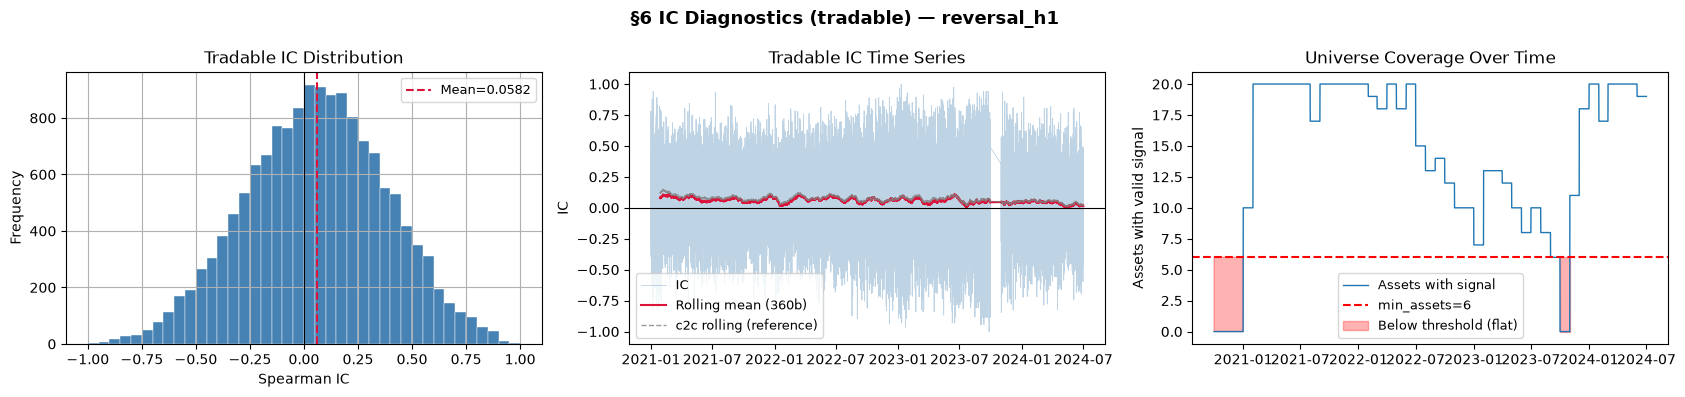

IC (tradable): mean=0.0582, NW t=21.88  |  IC (close-to-close): mean=0.0708, NW t=26.49  |  haircut=+0.0126


In [10]:
rolling_ic = rolling_mean(ic_series, window=settings["rolling_window_bars"])
rolling_ic_c2c = rolling_mean(ic_series_c2c, window=settings["rolling_window_bars"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle(f"\u00a76 IC Diagnostics (tradable) \u2014 {selected_signal_label}", fontsize=13, fontweight="bold")

# IC histogram
ax = axes[0]
ic_series.dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(ic_series.mean(), color="crimson", linestyle="--", label=f"Mean={ic_series.mean():.4f}")
ax.axvline(0, color="black", linestyle="-", linewidth=0.8)
ax.set_title("Tradable IC Distribution")
ax.set_xlabel("Spearman IC")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)

# IC time series + rolling mean
ax = axes[1]
ax.plot(ic_series.index, ic_series.values, alpha=0.35, color="steelblue", linewidth=0.6, label="IC")
ax.plot(rolling_ic.index, rolling_ic.values, color="crimson", linewidth=1.5,
        label=f"Rolling mean ({settings['rolling_window_bars']}b)")
ax.plot(rolling_ic_c2c.index, rolling_ic_c2c.values, color="gray", linestyle="--",
        linewidth=1.0, alpha=0.8, label="c2c rolling (reference)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Tradable IC Time Series")
ax.set_ylabel("IC")
ax.legend(fontsize=9)

# Coverage with min_assets threshold
ax = axes[2]
coverage = signal_for_ic.notna().sum(axis=1)
ax.plot(coverage.index, coverage, linewidth=1, label="Assets with signal")
ax.axhline(min_assets, linestyle="--", linewidth=1.5, color="red",
           label=f"min_assets={min_assets}")
ax.fill_between(coverage.index, coverage, min_assets,
                where=(coverage < min_assets),
                alpha=0.3, color="red", label="Below threshold (flat)")
ax.set_title("Universe Coverage Over Time")
ax.set_ylabel("Assets with valid signal")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"IC (tradable): mean={ic_series.mean():.4f}, "
      f"NW t={ic_summary(ic_series, nw_lag=nw)['t_stat_ic_nw']:.2f}  |  "
      f"IC (close-to-close): mean={ic_series_c2c.mean():.4f}, "
      f"NW t={ic_summary(ic_series_c2c, nw_lag=nw)['t_stat_ic_nw']:.2f}  |  "
      f"haircut={ic_series_c2c.mean() - ic_series.mean():+.4f}")


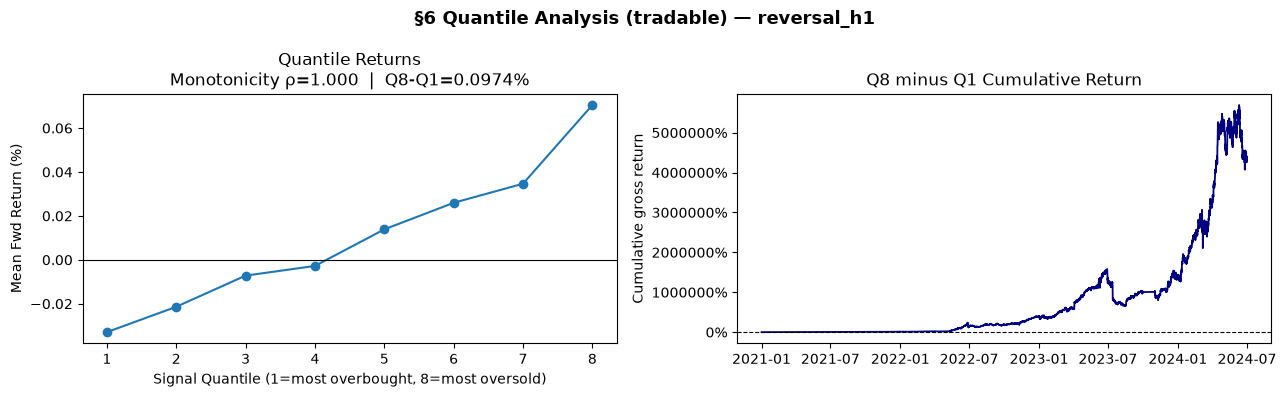

 quantile  mean_fwd_ret
        1       -0.0003
        2       -0.0002
        3       -0.0001
        4       -0.0000
        5        0.0001
        6        0.0003
        7        0.0003
        8        0.0007


In [11]:
n_quantiles = 8
# Priced on execution-delayed returns to match the tradable IC above.
q_means, spread_ts = quantile_analysis(
    signal_for_ic,
    tradable_fwd_ret_for_ic,
    n_quantiles=n_quantiles,
    returns_are_log=settings["log_returns"],
)

# Quantile 1 is the lowest signal / most overbought bucket; quantile 8 is the
# highest signal / most oversold bucket. A good reversal signal should therefore
# have forward returns that increase from Q1 to Q8.
fwd_rets_vec = q_means.set_index("quantile")["mean_fwd_ret"]
mono_corr = fwd_rets_vec.corr(
    pd.Series(range(1, n_quantiles + 1), index=fwd_rets_vec.index),
    method="spearman",
)
top_minus_bottom = spread_ts.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f"§6 Quantile Analysis (tradable) — {selected_signal_label}", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(q_means["quantile"], q_means["mean_fwd_ret"] * 100, marker="o")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Signal Quantile (1=most overbought, {n_quantiles}=most oversold)")
ax.set_ylabel("Mean Fwd Return (%)")
ax.set_title(f"Quantile Returns\nMonotonicity ρ={mono_corr:.3f}  |  Q{n_quantiles}-Q1={top_minus_bottom*100:.4f}%")
ax.set_xticks(range(1, n_quantiles + 1))

ax = axes[1]
spread_cumulative = (1 + spread_ts.dropna()).cumprod()
ax.plot(spread_cumulative.index, spread_cumulative.values, color="navy", linewidth=1.3)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Q{n_quantiles} minus Q1 Cumulative Return")
ax.set_ylabel("Cumulative gross return")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(q_means.to_string(index=False))

## §7 Backtest

Equal-weight top/bottom quantile long/short portfolio, gross vs net after fees and half-spread. Short-horizon mean reversion should show a Sharpe that is positive but sensitive to costs (high turnover erodes the net edge), and long/short legs that are balanced with low net market beta. Cost sensitivity is reported across one-way taker-fee tiers (`fee_tier_grid_bps`).

**Conventions.** The book rebalances every `holding_period_bars` on the freshest signal (decimation is an IC-analysis device and does not feed the backtest). With `use_minute_execution`, entry and exit prices are real 1-minute closes `execution_delay_minutes` after the signal close; filling at the very close the signal was computed on is the delta=0 point. Rebalances are netted at a single print; `fee_bps` and the half-spread are one-way rates charged on every fill, and weight drift within the hold is ignored (light backtest). Shorts are assumed available at no borrow cost; on spot they require margin (opening and rollover fees, eligible pairs only), which adds roughly a few bps per short at this 2-bar hold and does not change the verdict.


Minute execution: delta=1 min | direct 1,648,831 | LOCF fallback 57,700 | signal-close fallback 0 | unpriceable 0
Stale-fill exclusion ON: 57,700 fallback-filled cells removed from execution-priced returns


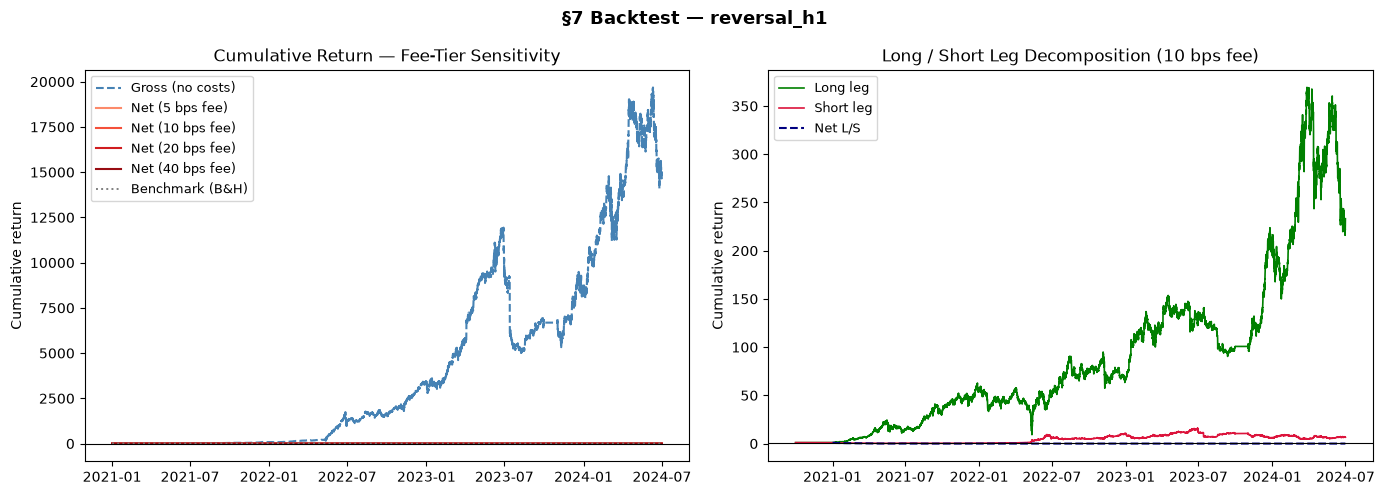


=== Backtest Metrics (one-way taker fee tiers) ===
        sharpe_net  max_drawdown_net  mean_turnover  annualized_turnover  mean_cost_per_period  n_periods
costs                                                                                                    
gross       3.6693           -0.5802         1.4862            6509.5152                0.0000      15253
5 bps      -5.5131           -1.0000         1.4862            6509.5152                0.0018      15253
10 bps    -13.1436           -1.0000         1.4862            6509.5152                0.0033      15253
20 bps    -28.2473           -1.0000         1.4862            6509.5152                0.0062      15253
40 bps    -57.2243           -1.0000         1.4862            6509.5152                0.0122      15253

Market correlation (net returns vs XBT/USD): -0.0048


In [12]:
# --- Backtest forward returns (execution-priced) ------------------------------
# Priced from the §4 execution cache at the headline delay.
if settings["use_minute_execution"]:
    _delta_base = int(settings["execution_delay_minutes"])
    # Stale-fill exclusion: a P&L period requires real prints at both the
    # entry and exit fill — LOCF / signal-close fallback fills are prices at
    # which no trade happened (mostly thin out-of-universe names).
    fwd_ret_bt = exec_prices.forward_returns(
        _delta_base,
        holding_period_bars=selected_holding_period,
        log_returns=settings["log_returns"],
    )
    _d = exec_prices.diagnostics(_delta_base)
    print(
        f"Minute execution: delta={_delta_base} min | direct {_d['n_direct']:,}"
        f" | LOCF fallback {_d['n_locf_fallback']:,}"
        f" | signal-close fallback {_d['n_signal_close_fallback']:,}"
        f" | unpriceable {_d['n_unpriceable']:,}"
    )
    print(
        f"Stale-fill exclusion ON: {_d['n_locf_fallback'] + _d['n_signal_close_fallback']:,} "
        f"fallback-filled cells removed from execution-priced returns"
    )
else:
    fwd_ret_bt = fwd_ret

# Gross book plus one net book per one-way taker-fee tier (flat half-spread).
_bt_common = dict(
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
    execution_delay_bars=settings["execution_delay_bars"],
    returns_are_log=settings["log_returns"],
    holding_period_bars=selected_holding_period,
)
fee_tiers = settings["fee_tier_grid_bps"]
bt_gross = run_light_backtest(
    selected_signal_fresh, fwd_ret_bt, fee_bps=0.0, half_spread_bps=0.0, **_bt_common
)
backtest_results = {
    fee: run_light_backtest(
        selected_signal_fresh, fwd_ret_bt,
        fee_bps=fee, half_spread_bps=settings["half_spread_bps"], **_bt_common,
    )
    for fee in fee_tiers
}
base_1x = backtest_results[settings["fee_bps"]]

# Benchmark buy-and-hold curve normalised to strategy start
benchmark_col = settings["benchmark_symbol"]
benchmark_px  = (close_wide[benchmark_col]
                 if benchmark_col in close_wide.columns
                 else close_wide.mean(axis=1))
benchmark_curve = benchmark_px.loc[benchmark_px.index >= base_1x["cum_net"].index[0]].ffill()
benchmark_curve = benchmark_curve / benchmark_curve.dropna().iloc[0]

# Cumulative PnL plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"\u00a77 Backtest \u2014 {selected_signal_label}", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(bt_gross["cum_gross"].index, bt_gross["cum_gross"].values,
        color="steelblue", linestyle="--", label="Gross (no costs)")
palette = plt.cm.Reds(np.linspace(0.4, 0.9, len(fee_tiers)))
for fee, color in zip(fee_tiers, palette):
    res = backtest_results[fee]
    ax.plot(res["cum_net"].index, res["cum_net"].values,
            color=color, label=f"Net ({fee:g} bps fee)")
ax.plot(benchmark_curve.index, benchmark_curve.values,
        color="gray", linestyle=":", linewidth=1.4, label="Benchmark (B&H)")
ax.axhline(1, color="black", linewidth=0.8)
ax.set_title("Cumulative Return \u2014 Fee-Tier Sensitivity")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)

# Leg decomposition (base case)
ax = axes[1]
long_ret, short_ret = long_short_leg_returns(
    base_1x["weights"], fwd_ret_bt.reindex(base_1x["weights"].index),
    returns_are_log=settings["log_returns"],
)
cum_long  = (1 + long_ret.dropna()).cumprod()
cum_short = (1 + short_ret.dropna()).cumprod()
ax.plot(cum_long.index, cum_long.values,   color="green",  linewidth=1.2, label="Long leg")
ax.plot(cum_short.index, cum_short.values, color="crimson", linewidth=1.2, label="Short leg")
ax.plot(base_1x["cum_net"].index, base_1x["cum_net"].values,
        color="navy", linestyle="--", linewidth=1.5, label="Net L/S")
ax.axhline(1, color="black", linewidth=0.8)
ax.set_title(f"Long / Short Leg Decomposition ({settings['fee_bps']:g} bps fee)")
ax.set_ylabel("Cumulative return")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Metrics summary
print("\n=== Backtest Metrics (one-way taker fee tiers) ===")
metrics_df = pd.DataFrame(
    {"gross": bt_gross["metrics"],
     **{f"{fee:g} bps": res["metrics"] for fee, res in backtest_results.items()}}
).T
metrics_df.index.name = "costs"
print(metrics_df[["sharpe_net", "max_drawdown_net", "mean_turnover",
                  "annualized_turnover", "mean_cost_per_period", "n_periods"]]
      .astype({"n_periods": int}).to_string())

# Benchmark correlation
benchmark_fwd_log = fwd_ret[benchmark_col].reindex(base_1x["net_returns"].index)
if settings["log_returns"]:
    benchmark_fwd = np.exp(benchmark_fwd_log) - 1.0
else:
    benchmark_fwd = benchmark_fwd_log
beta = market_correlation(base_1x["net_returns"], benchmark_fwd)
print(f"\nMarket correlation (net returns vs {benchmark_col}): {beta:.4f}")


### Data-Integrity Gate — Bar Labelling

Hourly and 1-minute bars are both labelled at bar open, so at zero delay the execution close must equal the stored hourly close on every bar with a real trade. The check below asserts this on the live data: an off-by-one-bar or off-by-one-minute labelling error would make it fail, rather than silently shifting every execution-priced return.


In [13]:
# --- Data-integrity gate: delta=0 execution close == stored hourly close ------
# Validates the bar-labelling convention against the *live* data. The logic
# is unit-tested on fixtures (_zero_delay_mismatch); this confirms the DB
# itself satisfies it. See assert_zero_delay_consistency in
# src/research/execution.py.
if settings["use_minute_execution"]:
    _chk = assert_zero_delay_consistency(
        engine, close_wide, volume_wide, symbols=list(close_wide.columns)
    )
    print(
        f"delta=0 execution close matches the hourly close on {_chk['n_cells']:,} "
        f"real-trade cells (max rel diff {_chk['max_rel_diff']:.3e}); "
        f"{_chk['n_synth_with_1m']:,} synthetic hourly bars had 1m trades (excluded)"
    )

delta=0 execution close matches the hourly close on 1,648,830 real-trade cells (max rel diff 0.000e+00); 1 synthetic hourly bars had 1m trades (excluded)


### Effective Spreads — Per-Asset Costs and the Bounce Floor

Two problems with a flat `half_spread_bps = 1` cost model: (i) it is roughly right for XBT/USD but off by an order of magnitude for the tail of the universe, and (ii) it says nothing about how much of the *gross* reversal P&L is mechanical bid-ask bounce. With spread *s*, close prints bounce between bid and ask, inducing a 1-lag autocovariance of about −s²/4 (the Roll model) with **zero** mid-price reversion — apparent reversal profit that a taker cannot capture, because entering the position pays the same half-spread that generated it.

Below: per-asset Corwin–Schultz half-spread estimates from **hourly** high/low ranges (stale hours excluded; mean with negatives floored, per the paper). The estimation bar matters: crypto trades 24/7, so a daily range is pure volatility next to a 5–50 bps spread and the estimator comes out vol-dominated: on this dataset daily bars put XBT/USD at ≈59 bps mean half-spread vs ≈10 bps at hourly bars. Hourly estimates still overstate the most liquid pairs (XBT/USD's real book is nearer 1 bp), so per-asset costs are conservative at the top of the universe. Then: the base backtest re-run with per-asset costs, and an order-of-magnitude **bounce floor** (`traded notional × mean half-spread`) compared against the gross per-period return.


In [14]:
# --- Per-asset effective spreads (Corwin-Schultz, hourly ranges) ---------------
half_spread_est, _cs_spread_panel = estimate_half_spread_bps_from_long(
    df_long, estimation_timeframe="1h", stat="mean"
)
half_spread_universe = (
    half_spread_est.reindex(close_wide.columns).dropna().sort_values()
)
print("=== Corwin-Schultz half-spread estimates (bps, mean over hourly bars) ===")
print(half_spread_universe.to_string(float_format=lambda x: f"{x:8.1f}"))
print(f"\nUniverse mean: {half_spread_universe.mean():.1f} bps | "
      f"flat assumption in config: {settings['half_spread_bps']:.1f} bps")

# --- Base backtest with per-asset spreads (same fee) ----------------------------
bt_flat = base_1x
bt_asset = run_light_backtest(
    selected_signal_fresh,
    fwd_ret_bt,
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
    fee_bps=settings["fee_bps"],
    half_spread_bps=half_spread_est,
    execution_delay_bars=settings["execution_delay_bars"],
    returns_are_log=settings["log_returns"],
    holding_period_bars=selected_holding_period,
)
_cost_keys = ["sharpe_net", "mean_cost_per_period", "annualized_turnover"]
print(f"\n=== Cost model comparison ({settings['fee_bps']:g} bps fee) ===")
print(pd.DataFrame({
    "flat_spread":      {k: bt_flat["metrics"][k] for k in _cost_keys},
    "per_asset_spread": {k: bt_asset["metrics"][k] for k in _cost_keys},
}).to_string())

# --- Bounce floor vs gross edge --------------------------------------------------
# If extreme-quantile membership were purely bounce-driven, the book earns about
# one half-spread per unit of traded notional (2x one-sided turnover) and gives
# it all back at execution. An order-of-magnitude floor, not a decomposition.
_gross_per_period = float(bt_flat["gross_returns"].mean())
_bounce_floor = float(
    2.0 * bt_flat["metrics"]["mean_turnover"] * half_spread_universe.mean() * 1e-4
)
print(f"\nMean gross return per period : {_gross_per_period * 1e4:8.2f} bps")
print(f"Bounce floor (traded x s/2)  : {_bounce_floor * 1e4:8.2f} bps")
if _bounce_floor > 0:
    print(f"Gross edge / bounce floor    : {_gross_per_period / _bounce_floor:8.2f}x")
if _gross_per_period <= _bounce_floor:
    print("-> The gross edge sits within the bid-ask bounce floor: consistent with "
          "bounce + stale prints rather than monetisable mid-price reversion.")
else:
    print("-> Gross edge exceeds the bounce floor: some mid-price reversion beyond "
          "pure bounce, but it must still clear fees + spread to trade.")


=== Corwin-Schultz half-spread estimates (bps, mean over hourly bars) ===
symbol
YFI/USD          8.4
TRX/USD          8.9
AXS/USD          8.9
LRC/USD          9.1
BAT/USD          9.4
DYDX/USD         9.7
XBT/USD          9.9
DASH/USD        10.0
SAND/USD        10.6
ETC/USD         10.6
ARB/USD         10.9
EOS/USD         10.9
ZEC/USD         11.3
WAVES/USD       11.4
ICP/USD         11.4
BCH/USD         11.6
OMG/USD         11.8
NEAR/USD        11.8
AKT/USD         11.9
ETH/USD         12.3
APE/USD         12.3
SNX/USD         12.8
XTZ/USD         12.8
XMR/USD         13.0
FLOW/USD        13.2
XLM/USD         13.2
FIL/USD         13.2
AAVE/USD        13.3
ENJ/USD         13.3
FTM/USD         13.3
INJ/USD         13.4
BLUR/USD        13.5
UNI/USD         13.6
KAVA/USD        13.7
AVAX/USD        13.9
SHIB/USD        13.9
STX/USD         14.1
LTC/USD         14.1
LDO/USD         14.3
XRP/USD         14.7
CRV/USD         14.9
MATIC/USD       15.1
GALA/USD        15.5
RNDR/USD        

## §8 Execution & Events

Stress-tests the §7 base-cost backtest for execution risks and regime dependence:

- **Rolling gross Sharpe** over `rolling_window_bars`: stability of the raw edge over time (the net verdict is §7's)
- **Execution delay** (minutes after the signal close, real 1m fills over `execution_delay_minutes_grid`): gross Sharpe by delay; the delta=0 vs delta=1m gap quantifies the look-ahead in filling at the signal's own close
- **Vol-regime conditioning**: does the signal earn more gross in high-volatility environments, where price extremes are more likely to revert?

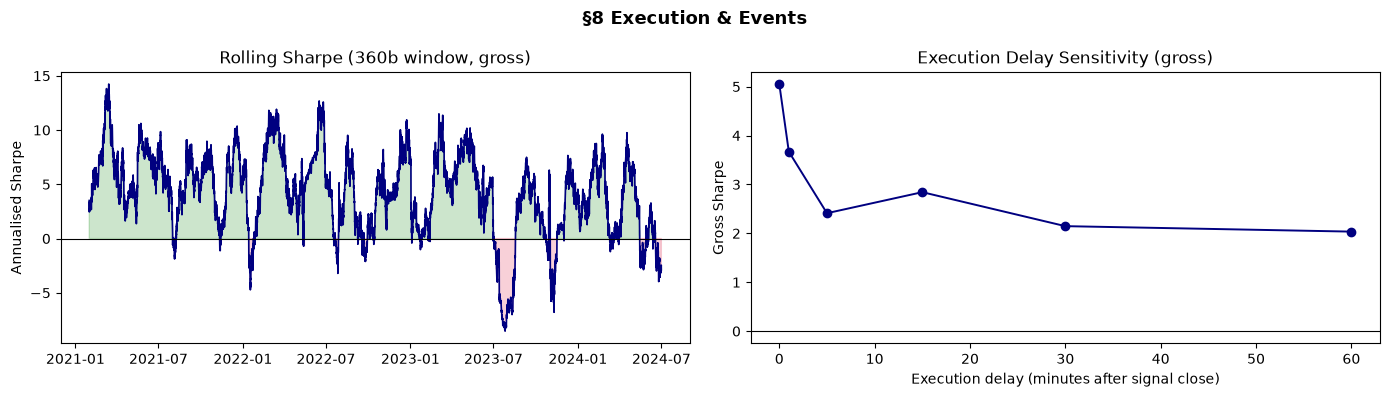

Execution delay sensitivity (gross vs net Sharpe):
           sharpe_gross  sharpe_net
delay_min                          
0                5.0528    -11.2219
1                3.6693    -13.1436
5                2.4116    -13.8981
15               2.8417    -14.2661
30               2.1467    -13.8348
60               2.0350    -14.7328

Leakage (gross): Sharpe(delta=0) - Sharpe(delta=1m) = 1.38 — the edge a naive same-close fill would over-count.


In [15]:
# --- Rolling Sharpe (gross) + execution-delay sensitivity (gross) ---------------
ppy = base_1x["metrics"]["periods_per_year"]
rsh = rolling_sharpe(
    base_1x["gross_returns"],
    window=settings["rolling_window_bars"],
    periods_per_year=ppy,
)

_bt_kwargs = dict(
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
    fee_bps=settings["fee_bps"],
    half_spread_bps=settings["half_spread_bps"],
    returns_are_log=settings["log_returns"],
    holding_period_bars=selected_holding_period,
)

# Same weight schedule at every delay: turnover (hence cost) is ~constant,
# so gross returns isolate alpha decay with latency.
if settings["use_minute_execution"]:
    delay_results = run_delay_sweep(
        selected_signal_fresh,
        exec_prices,
        settings["execution_delay_minutes_grid"],
        holding_period_bars=selected_holding_period,
        log_returns=settings["log_returns"],
        top_quantile=settings["top_quantile"],
        bottom_quantile=settings["bottom_quantile"],
        fee_bps=settings["fee_bps"],
        half_spread_bps=settings["half_spread_bps"],
    )
else:
    delay_results = {
        d: run_light_backtest(selected_signal_fresh, fwd_ret,
                              execution_delay_bars=d, **_bt_kwargs)
        for d in [0, 1]
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("§8 Execution & Events", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(rsh.index, rsh.values, color="navy", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.fill_between(rsh.index, rsh.values, 0, where=(rsh > 0), alpha=0.2, color="green")
ax.fill_between(rsh.index, rsh.values, 0, where=(rsh < 0), alpha=0.2, color="crimson")
ax.set_title(f"Rolling Sharpe ({settings['rolling_window_bars']}b window, gross)")
ax.set_ylabel("Annualised Sharpe")

# Delay sensitivity as a decay curve: gross Sharpe vs latency.
ax = axes[1]
_deltas = sorted(delay_results)
_sharpes_g = [gross_sharpe(delay_results[d]) for d in _deltas]
ax.plot(_deltas, _sharpes_g, marker="o", color="navy", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Execution Delay Sensitivity (gross)")
ax.set_xlabel("Execution delay (minutes after signal close)")
ax.set_ylabel("Gross Sharpe")

plt.tight_layout()
plt.show()

# Companion table: gross isolates alpha decay; net adds the ~constant cost.
_sweep_tbl = pd.DataFrame({
    "sharpe_gross": {d: gross_sharpe(r) for d, r in delay_results.items()},
    "sharpe_net":   {d: r["metrics"]["sharpe_net"] for d, r in delay_results.items()},
}).sort_index()
_sweep_tbl.index.name = "delay_min"
print("Execution delay sensitivity (gross vs net Sharpe):")
print(_sweep_tbl.to_string())
if 0 in delay_results and 1 in delay_results:
    _gap_g = gross_sharpe(delay_results[0]) - gross_sharpe(delay_results[1])
    print(f"\nLeakage (gross): Sharpe(delta=0) - Sharpe(delta=1m) = {_gap_g:.2f} "
          f"— the edge a naive same-close fill would over-count.")

In [16]:
# --- Volatility-regime conditioning (§8 cont.) -------------------------------
# High-vol bars via rolling realised vol of the benchmark. The quantile
# threshold uses the full sample (look-ahead): a regime *diagnostic*, not a
# tradable rule.
bench_ret = return_wide[settings["benchmark_symbol"]]
bench_vol = bench_ret.rolling(
    settings["rolling_window_bars"],
    min_periods=settings["rolling_window_bars"],
).std()
vol_q = bench_vol.quantile(settings["extreme_event_quantile"])
high_vol_mask = bench_vol >= vol_q

gross_ret = base_1x["gross_returns"]
mask_aligned = high_vol_mask.reindex(gross_ret.index).fillna(False)
mean_ret_high_vol = gross_ret[mask_aligned].mean()
mean_ret_low_vol  = gross_ret[~mask_aligned].mean()

print(f"Mean gross return - high vol regime (p{settings['extreme_event_quantile']*100:.0f}+): "
      f"{mean_ret_high_vol*100:.4f}%")
print(f"Mean gross return - low vol regime        : "
      f"{mean_ret_low_vol*100:.4f}%")
diff = mean_ret_high_vol - mean_ret_low_vol
direction = (
    "supports the hypothesis that mean reversion is stronger during high-vol "
    "(extreme-move) regimes"
    if diff > 0
    else "contradicts the high-vol-favours-reversion hypothesis on this sample - "
         "the signal performs *worse* in extreme regimes, suggesting trend / "
         "momentum dominates when volatility spikes"
)
print(f"\nHigh-vol minus low-vol mean gross return: {diff*100:+.4f}%  ->  {direction}.")

Mean gross return - high vol regime (p99+): 0.1791%
Mean gross return - low vol regime        : 0.0701%

High-vol minus low-vol mean gross return: +0.1090%  ->  supports the hypothesis that mean reversion is stronger during high-vol (extreme-move) regimes.


### Market-Beta Diagnostics

Diagnostics only: the reversal book is measured for market exposure but not hedged. **Ex-ante portfolio beta** (versus XBT/USD) shows the instantaneous market tilt the signal carries bar to bar; **realized beta**, split by up- and down-market regime, tests whether that tilt accumulates into directional P&L. With ~15k stepped observations, against ~90 in the momentum sleeve, these realized figures are statistically meaningful.

Ex-ante portfolio beta: mean |beta_p| = 0.164, p95 |beta_p| = 0.487 (beta coverage mean 1.000)
Realized on net P&L (n=15,253): beta_full=-0.0062, corr_full=-0.0048
Regime split: beta_up=0.0697 (n=7,731), beta_down=-0.0707 (n=7,514)


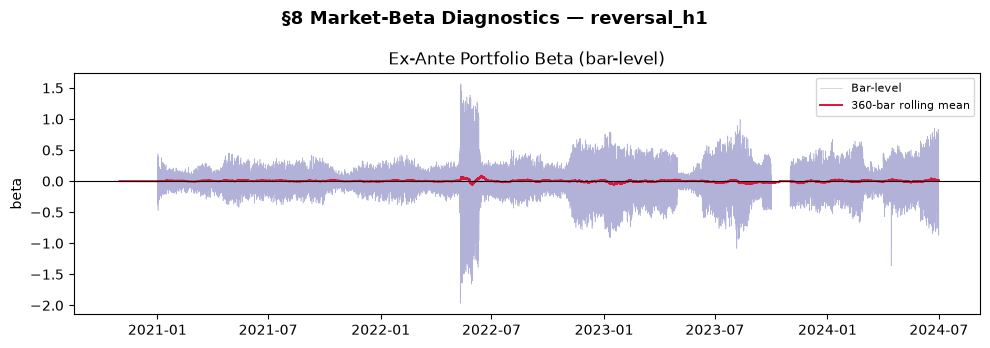

In [17]:
# --- Market-beta diagnostics ---------------------------------------------------
# Factor = the tradable benchmark (market_index_mode: benchmark -> XBT/USD),
# on simple returns. Betas on traded-masked returns: forward-filled no-trade
# bars print 0% and bias Cov/Var toward zero on illiquid names. Bar returns
# need both endpoints real -> lookback_bars=1.
_traded_for_beta = build_traded_mask(df_long, settings["signal_timeframe"])
_ret_traded = apply_traded_mask(return_wide, _traded_for_beta, lookback_bars=1)
_ret_traded_simple = to_simple_returns(_ret_traded, log_returns=settings["log_returns"])

market_ret = build_market_index_returns(
    _ret_traded_simple,
    mode=settings["market_index_mode"],
    benchmark_symbol=settings["benchmark_symbol"],
    universe_mask=universe_mask,
    min_assets=settings["min_assets_per_timestamp"],
)
betas = estimate_rolling_betas(
    _ret_traded_simple,
    market_ret,
    window_bars=settings["beta_window_bars"],
    min_periods=settings["beta_min_periods_bars"],
    shrinkage=settings["beta_shrinkage"],
    shrink_target=settings["beta_shrink_target"],
)

# Ex-ante beta of the traded book, bar by bar.
_qw_bar = build_quantile_weights(
    selected_signal_fresh,
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
)
beta_book = portfolio_beta_series(_qw_bar, betas)

# Realized regime-conditional beta on the minute-executed net P&L.
beta_realized = realized_beta_diagnostics(base_1x["net_returns"], benchmark_fwd)

print(
    f"Ex-ante portfolio beta: mean |beta_p| = "
    f"{float(beta_book['portfolio_beta'].abs().mean()):.3f}, "
    f"p95 |beta_p| = {float(beta_book['portfolio_beta'].abs().quantile(0.95)):.3f} "
    f"(beta coverage mean {float(beta_book['beta_coverage'].mean()):.3f})"
)
print(
    f"Realized on net P&L (n={beta_realized['n_obs']:,}): "
    f"beta_full={beta_realized['beta_full']:.4f}, corr_full={beta_realized['corr_full']:.4f}"
)
print(
    f"Regime split: beta_up={beta_realized['beta_up']:.4f} (n={beta_realized['n_up']:,}), "
    f"beta_down={beta_realized['beta_down']:.4f} (n={beta_realized['n_down']:,})"
)

_roll_w = settings["rolling_window_bars"]
_beta_roll = beta_book["portfolio_beta"].rolling(
    _roll_w, min_periods=_roll_w // 2
).mean()

fig, ax = plt.subplots(figsize=(10, 3.5))
fig.suptitle(f"\u00a78 Market-Beta Diagnostics \u2014 {selected_signal_label}", fontsize=13, fontweight="bold")
ax.plot(
    beta_book.index, beta_book["portfolio_beta"],
    linewidth=0.4, color="navy", alpha=0.3, label="Bar-level",
)
ax.plot(
    _beta_roll.index, _beta_roll,
    linewidth=1.4, color="crimson",
    label=f"{_roll_w}-bar rolling mean",
)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("Ex-Ante Portfolio Beta (bar-level)")
ax.set_ylabel("beta")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## §9 Robustness

Grid search over reversal lookback × holding period × universe size (cross-sectional rank; the transform axis is configurable). Each combination reports mean IC, NW-adjusted t-stat, net Sharpe, and train/test IC split. Results are sorted by mean IC; the heatmap below averages over nuisance parameters to show the lookback × holding surface.

Two additions correct the grid for selection: **selection-adjusted significance** (max-over-trials p-value for the best t-stat and a deflated Sharpe for the selected configuration) and **walk-forward evaluation with an embargo** (per-fold IC stability, plus re-selecting the best grid configuration at each fold using only past data and scoring it on the next fold). See the subsection after the heatmap.

In [18]:
# Feature family of the selected signal (e.g. 'reversal' from 'reversal_h1').
_fam_m = re.match(r"^(.*?)(?:_h\d+)?$", selected_feature_name)
_family_prefix = _fam_m.group(1) if _fam_m else selected_feature_name
_D_ic = int(settings["ic_rebalance_bars"])  # IC decimation only

# IC legs use close-to-close returns (raw predictive power); backtest legs price
# at minute execution when enabled, at the same delay as §7.
if settings["use_minute_execution"]:
    _fret_bt_cache = {
        h: exec_prices.forward_returns(
            int(settings["execution_delay_minutes"]),
            holding_period_bars=h,
            log_returns=settings["log_returns"],
        )
        for h in settings["holding_period_grid_bars"]
    }
else:
    _fret_bt_cache = {
        h: compute_forward_returns(close_wide, holding_period_bars=h, log_returns=settings["log_returns"])
        for h in settings["holding_period_grid_bars"]
    }
transform_grid = (
    settings["cross_sectional_transform_grid"]
    if apply_xsec_transform
    else [settings["cross_sectional_transform"]]
)

total_combos = (
    len(settings["momentum_lookback_grid_bars"]) * len(settings["holding_period_grid_bars"])
    * len(transform_grid) * len(settings["universe_top_n_grid"])
)
print(f"Running {total_combos} combinations  (feature family: {_family_prefix})...")

robustness_df, grid_ic_store, grid_nw_store = run_reversal_grid(
    close_wide,
    universe_df,
    settings,
    family=_family_prefix,
    backtest_forward_returns=_fret_bt_cache,
    ic_decimation_bars=_D_ic if apply_rebalance_decimation_flag else 1,
    transform_grid=transform_grid,
)

display_cols = ["lookback", "holding", "transform", "top_n",
                "mean_ic", "t_stat_ic", "t_stat_ic_nw",
                "train_mean_ic", "test_mean_ic",
                "train_t_stat_nw", "test_t_stat_nw",
                "sharpe_net", "annualized_turnover", "max_dd"]
print(f"\n=== Robustness Grid \u2014 {_family_prefix} (top 20 by mean IC) ===")
print(robustness_df[display_cols].head(20).to_string(index=False))


Running 32 combinations  (feature family: reversal)...

=== Robustness Grid — reversal (top 20 by mean IC) ===
 lookback  holding transform  top_n  mean_ic  t_stat_ic  t_stat_ic_nw  train_mean_ic  test_mean_ic  train_t_stat_nw  test_t_stat_nw  sharpe_net  annualized_turnover  max_dd
        1        1      rank     10   0.0818    25.7826       25.7826         0.1017        0.0663          21.5796         15.4861    -23.5131           13011.1680 -1.0000
        1        1      rank     20   0.0810    30.4383       30.4383         0.0992        0.0668          27.8552         17.4389    -27.0651           13339.8645 -1.0000
        2        1      rank     20   0.0743    27.7171       27.7171         0.0862        0.0650          24.0680         16.8136    -19.9011            9733.8325 -1.0000
        2        1      rank     10   0.0740    23.1592       23.1592         0.0852        0.0653          18.1196         15.0218    -17.1770            9465.4700 -1.0000
        1        2      

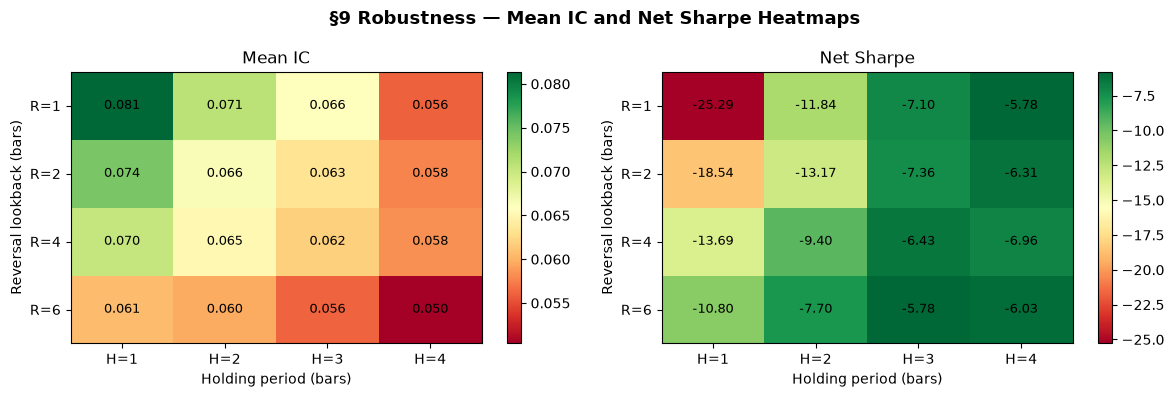

In [19]:
# Heatmap: mean IC by lookback × holding period (averaged over transform / top_n)
if not robustness_df.empty:
    pivot_ic = (
        robustness_df
        .groupby(["lookback", "holding"])["mean_ic"]
        .mean()
        .unstack("holding")
    )
    pivot_sharpe = (
        robustness_df
        .groupby(["lookback", "holding"])["sharpe_net"]
        .mean()
        .unstack("holding")
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("§9 Robustness — Mean IC and Net Sharpe Heatmaps",
                 fontsize=13, fontweight="bold")

    for ax, pivot, title, fmt in [
        (axes[0], pivot_ic,     "Mean IC",    "{:.3f}"),
        (axes[1], pivot_sharpe, "Net Sharpe", "{:.2f}"),
    ]:
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels([f"H={c}" for c in pivot.columns])
        ax.set_yticklabels([f"R={r}" for r in pivot.index])
        ax.set_xlabel("Holding period (bars)")
        ax.set_ylabel("Reversal lookback (bars)")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                ax.text(j, i, fmt.format(val), ha="center", va="center",
                        fontsize=9, color="black")

    plt.tight_layout()
    plt.show()

### Selection-Adjusted Significance & Walk-Forward

The grid above reports full-sample statistics for every combination — sorting it and quoting the winner is a **max-statistic**, not an unbiased estimate. Two corrections:

1. **Max-over-trials p-value** for the best NW t-stat: the correct null is the maximum of N trials, `1 − Φ(t)^N`. Trials are correlated, so the p-value is bracketed between the number of independent feature families and the total trial count. Alongside it, the **deflated Sharpe ratio** (Bailey–López de Prado) reports the probability that the selected configuration's true Sharpe exceeds the expected maximum of N no-skill trials; values near 0.5 mean the winner is indistinguishable from selection luck.
2. **Walk-forward with embargo**: per-fold IC of the selected signal over contiguous blocks (an embargo of the last overlapping lag separates folds so window overlap cannot leak), plus an out-of-sample grid evaluation that re-selects the best configuration on an expanding window of *past* observations and scores it on the next fold only. The pooled out-of-sample IC is what a fresh allocator following this process would actually have earned. A single train/test split cannot distinguish regime change from decay, and it quietly recycles test data once a winner is quoted.


In [20]:
# --- 1) Selection-adjusted significance -----------------------------------------
n_feature_trials = len(ic_table)        # section 5 feature scan
n_grid_trials    = len(robustness_df)   # section 9 grid
_best_t = float(robustness_df["t_stat_ic_nw"].max())

# Trials are correlated -> bracket the p-value between "independent families"
# and "every trial independent".
_n_families = 9  # reversal, price-z, vol-adj, extreme, volume, vwap, rsi, range, xsec-z
for _n in [_n_families, n_feature_trials + n_grid_trials]:
    print(f"P(max of {_n:>3} null trials >= t={_best_t:.2f}) = "
          f"{max_over_trials_pvalue(_best_t, _n):.4f}")

# Deflated Sharpe of the selected configuration vs the grid's trial distribution
# (all Sharpes converted to per-period units before comparing).
_ppy_base = float(base_1x["metrics"]["periods_per_year"])
_bars_per_year = _ppy_base * selected_holding_period
_sr_period_rows = robustness_df["sharpe_net"] / np.sqrt(_bars_per_year / robustness_df["holding"])
_net = base_1x["net_returns"].dropna()
_dsr = deflated_sharpe_ratio(
    sharpe=float(base_1x["metrics"]["sharpe_net"]) / np.sqrt(_ppy_base),
    n_obs=len(_net),
    n_trials=n_grid_trials,
    var_sharpe=float(_sr_period_rows.var(ddof=1)),
    skew=float(_net.skew()),
    kurt=float(_net.kurt()) + 3.0,
)
print(f"\nDeflated Sharpe (selected config, {n_grid_trials} trials): "
      f"P(true SR > expected max of noise) = {_dsr['deflated_sharpe_prob']:.3f} "
      f"(expected max per-period SR under null: {_dsr['expected_max_sharpe']:.4f})")

# --- 2) Walk-forward with embargo -------------------------------------------------
_embargo = nw + 1  # last overlapping lag of the IC series, in its own (subsampled) units
# Walk-forward significance uses the close-to-close IC (raw predictive power),
# matching the §9 grid convention; the tradable IC is the §5/§6 headline.
wf_table = walk_forward_ic_table(ic_series_c2c, n_folds=5, embargo_obs=_embargo, nw_lag=nw)
print("\n=== Walk-forward IC (selected signal) ===")
print(wf_table.to_string())

wf_sel_table, wf_pooled = walk_forward_selection(
    grid_ic_store,
    n_folds=5,
    embargo_obs=max(grid_nw_store.values()) + 1,
    nw_lag_by_config=grid_nw_store,
)
print("\n=== Walk-forward grid selection (select on past, score on next fold) ===")
print(wf_sel_table.to_string())
print(f"\nPooled out-of-sample IC: mean={wf_pooled['mean_ic']:.4f}, "
      f"NW t={wf_pooled['t_stat_ic_nw']:.2f} (n={wf_pooled['n_obs']})")


P(max of   9 null trials >= t=30.44) = 0.0000
P(max of  77 null trials >= t=30.44) = 0.0000

Deflated Sharpe (selected config, 32 trials): P(true SR > expected max of noise) = 0.000 (expected max per-period SR under null: 0.0913)

=== Walk-forward IC (selected signal) ===
                         start                       end  n_obs  mean_ic  t_stat_ic_nw
fold                                                                                  
1    2021-01-01 00:00:00+00:00 2021-09-07 02:00:00+00:00   2987   0.0941       17.1628
2    2021-09-07 06:00:00+00:00 2022-05-14 02:00:00+00:00   2987   0.0736       14.4179
3    2022-05-14 06:00:00+00:00 2023-01-18 02:00:00+00:00   2987   0.0768       12.2318
4    2023-01-18 06:00:00+00:00 2023-09-24 04:00:00+00:00   2987   0.0677        9.5472
5    2023-09-24 08:00:00+00:00 2024-06-30 20:00:00+00:00   2987   0.0411        7.2439

=== Walk-forward grid selection (select on past, score on next fold) ===
        selected_config  selection_mean_ic  

## §10 Low-Turnover Construction — Composite Signal + Hysteresis Bands

The fast reversal is statistically real but uneconomic: ~6,500× annualised turnover against a gross edge that sits inside the bid-ask bounce floor. This section asks whether the *same* dislocation effect, measured over slower windows and harvested with a deliberately low-churn book, clears realistic costs.

Slower windows change less from bar to bar and averaging smooths them further, so the composite is built to lower turnover, not to raise IC. The test is deliberately joint (slower windows, composite and bands together), asking whether any low-churn version of the effect survives; the constituent ICs below show the slow windows still carry signal individually.

**Pre-specified design (fixed before any results below were computed):**

- **Composite signal**: equal-weight average of six cross-sectionally z-scored panels: {raw reversal, vol-adjusted reversal} × {12h, 24h, 48h}. A combination rule fixed a priori counts as **one trial** in the multiple-testing accounting; constituent ICs are shown for context only, not for selection.
- **Primary configuration**: hold H = 12 bars; hysteresis band 0.10 (enter at the top/bottom 20% percentile rank, exit only beyond quantile ± band); membership evolves at decision frequency (every H bars). Named here, *before* the numbers.
- **Costs & fills**: minute execution at δ = 1 min with stale-fill exclusion, institutional one-way taker fee (`fee_bps`), per-asset Corwin–Schultz half-spreads (flat 1 bp and gross shown for attribution).
- **Success criterion**: annualised turnover in the tens-to-low-hundreds with **net Sharpe > 0 at per-asset costs**, and same-sign per-fold net Sharpe across embargoed folds. Anything else is a negative result and is written up as one.
- **Sensitivity grid**: H ∈ {6, 12, 24} × band ∈ {0, 0.05, 0.10, 0.20}: 12 trials, reported with a deflated-Sharpe correction. The grid contextualises the primary configuration; it does not replace it.

The banded book also gets the §8 beta treatment: slower books hold positions longer, so market-beta drift can be worse than the fast book's. It is measured below, with the hedge overlay available if needed.


In [21]:
# --- Phase 2 primary: slow composite -> banded book -> realistic costs ---------
slow_horizons = [12, 24, 48]
H_slow, band_primary = 12, 0.10

feat_slow_rev = build_return_reversal_features(
    close_wide, slow_horizons,
    log_returns=settings["log_returns"], universe_mask=universe_mask,
)
feat_slow_vol = build_vol_adjusted_move(
    close_wide, slow_horizons,
    vol_window_bars=settings["vol_window_bars"], log_returns=settings["log_returns"],
)
composite_panels = {}
for _h in slow_horizons:
    composite_panels[f"reversal_h{_h}"] = _mask_to_universe(feat_slow_rev[_h]["reversal"])
    composite_panels[f"vol_adj_reversal_h{_h}"] = _mask_to_universe(
        feat_slow_vol[_h]["vol_adj_reversal"]
    )

composite_raw = build_composite_signal(
    composite_panels, min_assets_per_timestamp=min_assets, min_features=2
)
composite_signal_fresh = cross_sectional_rank_or_zscore(
    composite_raw, method=settings["cross_sectional_transform"],
    min_assets_per_timestamp=min_assets,
)

# IC context (close-to-close, H=12; the 48-bar constituent dominates the NW lag).
fwd_slow = compute_forward_returns(
    close_wide, holding_period_bars=H_slow, log_returns=settings["log_returns"]
)
fwd_slow_u = _mask_to_universe(fwd_slow)
_nw_slow = max(H_slow, max(slow_horizons)) - 1
_ic_rows = []
for _name, _panel in {**composite_panels, "composite (pre-specified)": composite_signal_fresh}.items():
    _s = ic_summary(
        compute_ic_series(_panel, fwd_slow_u, min_assets=min_assets), nw_lag=_nw_slow
    )
    _ic_rows.append({"feature": _name, "mean_ic": _s["mean_ic"],
                     "t_stat_ic_nw": _s["t_stat_ic_nw"], "n_obs": _s["n_obs"]})
print("=== Slow-window IC: constituents (context only) vs composite ===")
print(pd.DataFrame(_ic_rows).set_index("feature").to_string())

# Banded book evolved at decision frequency (every H bars), on the full index.
w_banded_full = build_banded_book(
    composite_signal_fresh,
    holding_period_bars=H_slow,
    band=band_primary,
    top_quantile=settings["top_quantile"],
    bottom_quantile=settings["bottom_quantile"],
)

fwd_exec_slow = exec_prices.forward_returns(
    _delta_base, holding_period_bars=H_slow, log_returns=settings["log_returns"]
)

_bt_kwargs_slow = dict(
    signal_wide=None, forward_return_wide=fwd_exec_slow, weights_wide=w_banded_full,
    execution_delay_bars=settings["execution_delay_bars"],
    returns_are_log=settings["log_returns"], holding_period_bars=H_slow,
)
bt_slow_gross = run_light_backtest(fee_bps=0.0, half_spread_bps=0.0, **_bt_kwargs_slow)
bt_slow_flat = run_light_backtest(
    fee_bps=settings["fee_bps"], half_spread_bps=settings["half_spread_bps"], **_bt_kwargs_slow
)
bt_slow_asset = run_light_backtest(
    fee_bps=settings["fee_bps"], half_spread_bps=half_spread_est, **_bt_kwargs_slow
)

_cols = ["sharpe_net", "max_drawdown_net", "annualized_turnover",
         "mean_cost_per_period", "mean_gross_exposure", "n_periods"]
_cmp = {
    "fast book (flat 1bp)": base_1x["metrics"],
    "slow banded (gross)": bt_slow_gross["metrics"],
    "slow banded (flat 1bp)": bt_slow_flat["metrics"],
    "slow banded (per-asset)": bt_slow_asset["metrics"],
}
print(f"\n=== Fast vs slow book ({settings['fee_bps']:g} bps fee) ===")
print(pd.DataFrame({k: {c: v.get(c) for c in _cols} for k, v in _cmp.items()}).T.to_string())

# Per-fold net Sharpe; embargo = signal-window overlap in decision units.
_ppy_slow = float(bt_slow_asset["metrics"]["periods_per_year"])
_embargo_slow = int(np.ceil((max(slow_horizons) - 1) / H_slow))
print("\n=== Per-fold net Sharpe (primary config, per-asset costs) ===")
print(walk_forward_sharpe_table(
    bt_slow_asset["net_returns"], periods_per_year=_ppy_slow,
    n_folds=5, embargo_obs=_embargo_slow,
).to_string())

# Beta diagnostics on the banded book (betas from the section-8 cell).
beta_book_slow = portfolio_beta_series(w_banded_full, betas)
_bench_col = settings["benchmark_symbol"]
_bench_slow = (
    np.exp(fwd_slow[_bench_col]) - 1.0 if settings["log_returns"] else fwd_slow[_bench_col]
)
beta_real_slow = realized_beta_diagnostics(
    bt_slow_asset["net_returns"],
    _bench_slow.reindex(bt_slow_asset["net_returns"].index),
)
print(
    f"\nEx-ante |beta_p| (banded book): mean "
    f"{float(beta_book_slow['portfolio_beta'].abs().mean()):.3f}, "
    f"p95 {float(beta_book_slow['portfolio_beta'].abs().quantile(0.95)):.3f} "
    f"(coverage {float(beta_book_slow['beta_coverage'].mean()):.3f})"
)
print(
    f"Realized on net P&L: full={beta_real_slow['beta_full']:.4f}, "
    f"up={beta_real_slow['beta_up']:.4f} (n={beta_real_slow['n_up']:,}), "
    f"down={beta_real_slow['beta_down']:.4f} (n={beta_real_slow['n_down']:,})"
)


=== Slow-window IC: constituents (context only) vs composite ===
                           mean_ic  t_stat_ic_nw  n_obs
feature                                                
reversal_h12                0.0347        7.3833  29892
vol_adj_reversal_h12        0.0243        5.2265  29892
reversal_h24                0.0258        4.8343  29892
vol_adj_reversal_h24        0.0048        0.9639  29892
reversal_h48                0.0274        5.0199  29892
vol_adj_reversal_h48        0.0148        2.9013  29892
composite (pre-specified)   0.0274        5.3207  29892

=== Fast vs slow book (10 bps fee) ===
                         sharpe_net  max_drawdown_net  annualized_turnover  mean_cost_per_period  mean_gross_exposure  n_periods
fast book (flat 1bp)       -13.1436           -1.0000            6509.5152                0.0033               1.9511 15253.0000
slow banded (gross)         -1.3822           -0.9951             698.8358                0.0000               2.0000  2547.0000
slow

In [22]:
# --- Sensitivity grid: H x band (12 trials; the primary above was pre-specified) --
_grid_H, _grid_band = [6, 12, 24], [0.0, 0.05, 0.10, 0.20]
band_grid_rows = []
for _hg in _grid_H:
    _fwd_hg = exec_prices.forward_returns(
        _delta_base, holding_period_bars=_hg, log_returns=settings["log_returns"]
    )
    for _bg in _grid_band:
        _w = build_banded_book(
            composite_signal_fresh, holding_period_bars=_hg, band=_bg,
            top_quantile=settings["top_quantile"],
            bottom_quantile=settings["bottom_quantile"],
        )
        _bt = run_light_backtest(
            signal_wide=None, forward_return_wide=_fwd_hg,
            weights_wide=_w,
            fee_bps=settings["fee_bps"], half_spread_bps=half_spread_est,
            execution_delay_bars=settings["execution_delay_bars"],
            returns_are_log=settings["log_returns"], holding_period_bars=_hg,
        )
        band_grid_rows.append({
            "H": _hg, "band": _bg,
            "sharpe_net": _bt["metrics"]["sharpe_net"],
            "annualized_turnover": _bt["metrics"]["annualized_turnover"],
            "max_dd": _bt["metrics"]["max_drawdown_net"],
            "mean_cost_per_period": _bt["metrics"]["mean_cost_per_period"],
            "periods_per_year": _bt["metrics"]["periods_per_year"],
        })
band_grid = (
    pd.DataFrame(band_grid_rows).sort_values("sharpe_net", ascending=False).reset_index(drop=True)
)
print("=== H x band sensitivity (per-asset costs, sorted by net Sharpe) ===")
print(band_grid.to_string(index=False))

# Selection correction: the grid's best row judged as the max of 12 trials.
_sr_period_grid = band_grid["sharpe_net"] / np.sqrt(band_grid["periods_per_year"])
_best_row = band_grid.iloc[0]
_net_primary = bt_slow_asset["net_returns"].dropna()
_dsr_grid = deflated_sharpe_ratio(
    sharpe=float(_best_row["sharpe_net"]) / np.sqrt(float(_best_row["periods_per_year"])),
    n_obs=int(_net_primary.shape[0]),
    n_trials=len(band_grid),
    var_sharpe=float(_sr_period_grid.var(ddof=1)),
    skew=float(_net_primary.skew()),
    kurt=float(_net_primary.kurt()) + 3.0,
)
print(
    f"\nBest grid row: H={int(_best_row['H'])}, band={_best_row['band']:.2f} -> "
    f"DSR vs {len(band_grid)} trials: P(true SR > expected max of noise) = "
    f"{_dsr_grid['deflated_sharpe_prob']:.3f}"
)
print(
    "The claim rests on the pre-specified primary (H=12, band=0.10), not the grid argmax; "
    "the grid shows how sensitive the economics are to cadence and churn."
)


=== H x band sensitivity (per-asset costs, sorted by net Sharpe) ===
 H   band  sharpe_net  annualized_turnover  max_dd  mean_cost_per_period  periods_per_year
24 0.2000     -2.8965             381.6156 -0.9999                0.0052          365.0000
24 0.1000     -3.1413             439.0442 -1.0000                0.0060          365.0000
24 0.0000     -3.1901             482.4658 -1.0000                0.0065          365.0000
24 0.0500     -3.1948             458.9612 -1.0000                0.0062          365.0000
12 0.2000     -5.0520             596.2823 -1.0000                0.0040          730.0000
12 0.1000     -5.6153             698.8358 -1.0000                0.0047          730.0000
12 0.0500     -5.8450             733.9648 -1.0000                0.0050          730.0000
12 0.0000     -5.8773             788.1079 -1.0000                0.0053          730.0000
 6 0.2000     -7.1487             844.8841 -1.0000                0.0029         1460.0000
 6 0.1000     -7.9889

## §11 Detailed Findings

**Significance and robustness**
- The one-bar reversal has close-to-close mean IC 0.071 (NW t 26.5) at the selected 2-bar hold; the §9 grid's highest-t row reaches 0.081 (NW t 30.4). The max-over-trials p-value is ≈ 0 whether trials are counted as 9 feature families or all 77 scans (§9).
- Walk-forward IC across five embargoed folds is 0.094, 0.074, 0.077, 0.068, 0.041: decaying, but significant in every fold. Re-selecting the best grid configuration at each fold using only past data, then scoring it on the next fold, gives a pooled out-of-sample IC of 0.071 (NW t 21.0) (§9).
- Masking forward-filled no-trade bars moves the IC by at most 0.0001: the monthly liquidity filter already excludes the thin names (§5).

**Market neutrality**
- Mean |ex-ante β| is 0.16 against XBT/USD, but the book turns over fast enough that realized regime betas are ≈ ±0.07 across ~15k observations (§8).

**Execution latency**
- Fills use real 1-minute prints after the signal close; LOCF-carried fills are excluded. Moving from δ = 0 (filling at the print that formed the signal) to δ = 1 minute costs 1.4 gross Sharpe (5.1 → 3.7); gross Sharpe falls to ≈ 2.0 by δ = 60 minutes (§8).
- Tradable IC is 18% below close-to-close (0.058 vs 0.071); the haircut is largest at the shortest holds (§5).

**Costs and the bounce floor**
- Corwin–Schultz half-spreads from hourly ranges are ≈ 8–18 bps for most names (universe mean ≈ 14 bps; XBT/USD ≈ 10 bps). The gross edge of 7.1 bps per period is 0.17× the bounce floor (traded notional × mean half-spread ≈ 43 bps), consistent with harvesting the bounce of other traders' prints (§7).
- Turnover annualises to ~6,500×. With a flat 1 bp half-spread, net Sharpe is −5.5 at the 5 bps top tier, −13.1 at the 10 bps headline and −57.2 at the 40 bps retail rate; with per-asset spreads it is −34.0 at 10 bps (§7).

**Low-turnover construction (§10)**
- The pre-specified composite of 12–48h reversal features has IC 0.027 (NW t 5.3), counted as one trial. Hysteresis-banded weights cut annualised turnover from 6,510× to 699×, but gross Sharpe is −1.4 and net −5.6 at per-asset costs. All 12 H × band configurations and every walk-forward fold are negative.
- The banded book stays market-neutral (mean |ex-ante β| ≈ 0.15; realized β ≈ 0 in both regimes).
- Holding long enough to afford the trading lets the dislocations resolve first. Maker execution or perpetual futures (tighter spreads, cheap two-sided shorting, funding data, ~10× the breadth) change both sides of that trade-off.
